<a href="https://colab.research.google.com/github/Jagathateja/Seasonal_Agriculture_Performance/blob/main/Seasonal_Agriculture_Performance_Data_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Major Data Analytics project

**Domain** : Agriculture

**Project** **Theme** : Seasonal Agriculture Performance

**Tools** : Python,Pandas,NumPy,Matplotlib,Seaborn

# Project Goal

Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.


# 1. Problem statement
Agricultural activities are influenced by seasonal variations in environmental conditions,
 farming practices, resource availability and economic conditions. As a result, agricultural
 performance may differ from one season to another.

The objective of the project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data

#2. Project Objectives
* Explore and understand the dataset.  
* Clean and prepare the data for analysis.  
* Examine how agricultural performance varies across seasons.  
* Identify important seasonal patterns and trends.  
* Investigate relationships between seasonal conditions and agricultural outcomes.  
* Compare relevant groups within different seasons.  
* Identify significant differences or unusual patterns.  
* Apply appropriate statistical and visualization techniques.  
* Interpret findings based on evidence from the dataset.  
* Develop meaningful conclusions and data-driven recommendations.

# 3. Dataset
The data set contains farm-level agricultural records covering different seasons, locations, crops and environmental conditions, farming production, costs, revenue, profit and resource usage.

Dataset file:[seasonal_agriculture_performance_dataset.csv](https://drive.google.com/file/d/1J-dt_EOYRhqUwPeJ6HQIXLjYvRNvQl1q/view?usp=drivesdk)

In [ ]:
# import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format",lambda x:f"{x:,.2f}")

In [ ]:
#loading dataset
file_path = "/content/drive/MyDrive/seasonal_agriculture_performance_dataset.xlsx"
data = pd.read_excel(file_path)

print("data loading completed.")

data loading completed.


# 4.Intitial Data Understanding

In [ ]:
#dataset shape
data.shape

print("data shape",data.shape)
print("No of Rows:",data.shape[0])
print("no of Colunms:",data.shape[1])


data shape (4000, 28)
No of Rows: 4000
no of Colunms: 28


In [ ]:
#First 5 Rows
data.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [ ]:
#last 5 Rows
data.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [ ]:
# Random sample of records
data.sample(5,random_state=59)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
1551,SF11552,Karnataka,Krishna,Cotton,Rabi,8.62,317.30,20.30,58.60,8.40,6.67,19.50,109.20,48.70,125.50,Flood,104.60,2.40,0.98,1.52,13.10,59005,513161,772966,259805,9524,1.38,45.40
1336,SF11337,Karnataka,Nashik,Wheat,Rabi,10.28,455.10,23.00,62.20,7.20,6.71,25.00,113.00,62.20,105.70,Drip,140.60,4.67,0.87,3.03,31.15,25818,677923,804231,126308,4572,6.81,47.80
3643,SF13644,Gujarat,Indore,Groundnut,Kharif,9.96,827.50,28.50,72.50,6.10,7.60,30.40,68.40,54.70,119.90,Drip,210.40,3.60,0.91,0.66,6.57,54691,733833,359320,-374513,4145,1.58,61.30
500,SF10501,Karnataka,Nalgonda,Chilli,Zaid,4.50,340.70,32.10,41.60,8.70,5.29,20.10,112.80,57.70,115.90,Flood,155.50,6.22,0.87,0.30,1.35,102732,260067,138688,-121379,4027,0.34,43.20
2240,SF12241,Karnataka,Warangal,Wheat,Kharif,14.15,668.00,29.90,61.30,7.30,6.84,24.10,160.40,53.70,94.70,Flood,277.20,2.67,0.68,3.52,49.81,22824,1014587,1136863,122276,8920,5.58,63.80


In [ ]:
#column names
print(data.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [ ]:
#Data Types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
#Numerical Data

data.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [ ]:
# Categorical data

data.describe(include='object')

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


# 5.Data Quality Analysis

Before performing analysis,investigate missing values,duplicates,data types and unusual values.

In [ ]:
# Missing Values
missing = data.isnull().sum().sort_values(ascending=False)
missing_percentage = (data.isnull().mean()*100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing_Count":missing,
    "Missing_Percentage":missing_percentage.round(2)
})
missing_summary[missing_summary["Missing_Count"]>0]



,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


By this code The output shows that less than 1.2% of data is missing across three key environmental and crop yield variables, meaning no columns need to be deleted.

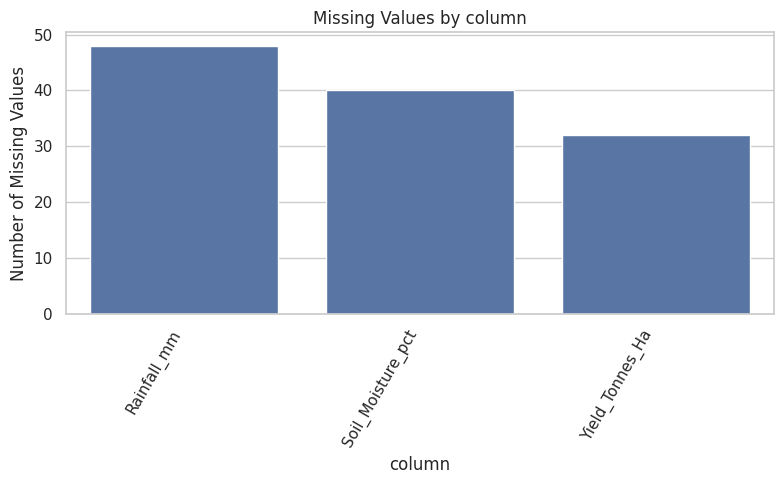

In [ ]:
#visualize missing values
plt.figure(figsize=(8,5))
missing_plot = missing[missing>0]
if len(missing_plot)>0:
  sns.barplot(x=missing_plot.index,y=missing_plot.values)
  plt.xticks(rotation=60,ha="right")
  plt.ylabel("Number of Missing Values")
  plt.xlabel("column")
  plt.title("Missing Values by column")
  plt.tight_layout()
  plt.show()
else:
  print("No missing values found")

# Graphical Representation of missing values

by barplot we can show missing values like this

In [ ]:
# Duplicate Records

dupilcates = data.duplicated().sum()
print("Number of duplicate records:",dupilcates)

Number of duplicate records: 0


duplicated count is zero

In [ ]:
# Remove duplicate rows

data = data.drop_duplicates().reset_index(drop=True)
print("shape after duplicates removed",data.shape)

shape after duplicates removed (4000, 28)


shape remains same after removing duplicate records, simply we can say there is no duplicate records

In [ ]:
# checking data types again
data.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [ ]:
# check unique values for categorical columns

categorical_columns=data.select_dtypes(include="object").columns

for col in categorical_columns:
  print(f"\n{col}:")
  print(data[col].nunique(), "unique values")
  print(data[col].dropna().unique()[:20])



Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [ ]:
# check missing values after duplicate removal

data.isnull().sum().sort_values(ascending=False).head(10)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


# Missing value treatment

Choose an appropriate strategy based on the nature of each variable.

Possible approaches:

  Remove records only when justified.

  Fill numerical values using an appropriate statistic when appropriate.

  Fill categorical values using a suitable category or method.

  Clearly document why the chosen approach is reasonable.


In [ ]:
numeric_columns = data.select_dtypes(include=np.number).columns

for col in numeric_columns:

    if data[col].isnull().sum() > 0:
       data [col]= data[col].fillna(data[col].median())

print("Remaining missing values:", data.isnull().sum().sum())

Remaining missing values: 0


# 6. Feature / Variable Review

Review the available variables and classify them conceptually as:

Identifier variables

Categorical variables

Numerical variables

Environmental variables

Operational variables

Production/performance variables

Economic variables

In [ ]:
# Numerical and categorical columns
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
categorical_columns = data.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

# Classifying variables based on their nature and relevance to seasonal performance

# Identifier Variable: Uniquely identifies each farm, not directly used for performance analysis.
identifier_variables = ['Farm_ID']

# Categorical Variables: Represent qualitative data, crucial for grouping and comparative analysis.
categorical_variables_classified = [
    'State', # Regional variations in agriculture
    'District', # Local variations
    'Crop', # Different crops have different seasonal requirements
    'Season', # Primary variable for seasonal performance analysis
    'Irrigation_Method' # Farming practices that might vary by season
]

# Numerical Variables: Quantitative data, further divided into sub-categories based on their role.

# Environmental Variables: Directly influenced by season and impact agricultural conditions.
environmental_variables = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct'
]

# Operational Variables: Inputs and practices managed by farmers.
operational_variables = [
    'Farm_Area_Hectares',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Water_Used_m3'
]

# Production/Performance Variables: Measure the direct output and efficiency of farming.
production_performance_variables = [
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

# Economic Variables: Financial outcomes of agricultural activities.
economic_variables = [
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR'
]

print("\n--- Variable Classification and Relevance ---")
print("\nIdentifier Variables (Not directly relevant for performance analysis):")
print(identifier_variables)

print("\nCategorical Variables (Relevant for grouping and understanding variations):")
print(f"  - 'State', 'District': Geographical context influencing local conditions and practices.")
print(f"  - 'Crop': Different crops have varying optimal growing seasons.")
print(f"  - 'Season': **Most relevant**, as it's the core variable to analyze seasonal performance differences.")
print(f"  - 'Irrigation_Method': Farming practice that can adapt to seasonal water availability.")

print("\nEnvironmental Variables (Directly relevant for seasonal impact analysis):")
print(f"  - 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct': These factors are directly dictated by seasons and significantly influence crop growth and yield.")

print("\nOperational Variables (Relevant as farmer responses to seasonal conditions and inputs affecting outcomes):")
print(f"  - 'Farm_Area_Hectares': Scale of operation.")
print(f"  - 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Water_Used_m3': These are inputs that can be adjusted seasonally to optimize performance.")

print("\nProduction/Performance Variables (Key metrics to evaluate seasonal performance):")
print(f"  - 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct': These are the primary outcomes that reflect agricultural success or failure in a given season.")

print("\nEconomic Variables (Relevant for understanding the financial implications of seasonal performance):")
print(f"  - 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR': These indicate the financial viability and profitability across different seasons.")


Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']

--- Variable Classification and Relevance ---

Identifier Variables (Not directly relevant for performance analysis):
['Farm_ID']

Categorical Variables (Relevant for grouping and understanding variations):
  - 'State', 'District': Geographical context influencing local conditions and practices.
  - 'Crop': Different crops have varying optimal growing seasons.
  - 'Season': **Most relevant**, as it's the core variable to analyze seasonal perfor

# 7. Statistical Analysis

Performing descriptive statistical analysis to understand the distribution and variation of the data.

In [ ]:
# Descriptive statistics

stats=data[numeric_columns].describe().T

stats ["range"] = stats["max"]- stats["min"]
stats["IQR"] = stats["75%"]- stats["25%"]

stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20","1,315.20",460.40
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [ ]:
#Median and standard deviation

statistical_summary =pd.DataFrame ({

    "Mean": data [numeric_columns].mean(),

    "Median": data [numeric_columns].median(),

    "Std_Dev": data [numeric_columns].std(),

    "Min": data[numeric_columns].min(),

    "Max": data [numeric_columns].max()

})

statistical_summary

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [ ]:
season_summary = data.groupby("Season")[numeric_columns].agg(["mean"],"median","std")

season_summary

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean
Season,,,,,,,,,,,,,,,,,,,,,,
Kharif,7.94,849.20,28.45,71.81,6.79,6.73,31.15,120.02,58.10,105.30,187.08,5.08,0.82,5.63,46.31,"44,850.91","531,804.41","710,719.06","178,914.65","6,102.20",5.89,54.47
Rabi,7.75,437.62,23.49,57.89,7.59,6.67,24.07,120.40,57.31,103.93,185.41,5.02,0.83,5.04,41.49,"44,747.97","513,836.58","601,526.05","87,689.47","5,846.99",5.19,40.48
Zaid,8.09,304.65,31.04,52.01,8.18,6.69,19.28,120.53,58.13,105.42,184.64,5.17,0.82,4.64,38.89,"44,212.03","543,976.73","519,171.90","-24,804.82","6,419.89",4.41,38.22


#8.Univariate analysis
Creating and interpreting suitable plots for:

Important categorical variables

Important numerical variables

Seasonal distribution

Production/performance distributions

Economic distributions

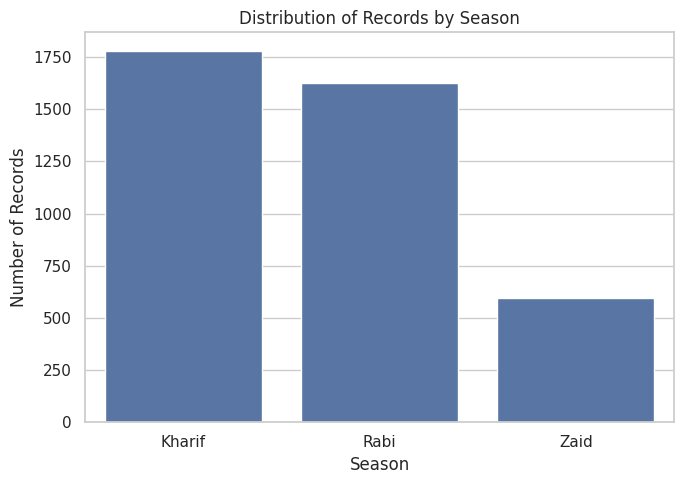

In [ ]:
#Univariate: Season distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=data, x="Season")

plt.title("Distribution of Records by Season")

plt.xlabel("Season")

plt.ylabel("Number of Records")

plt.tight_layout()

plt.show()

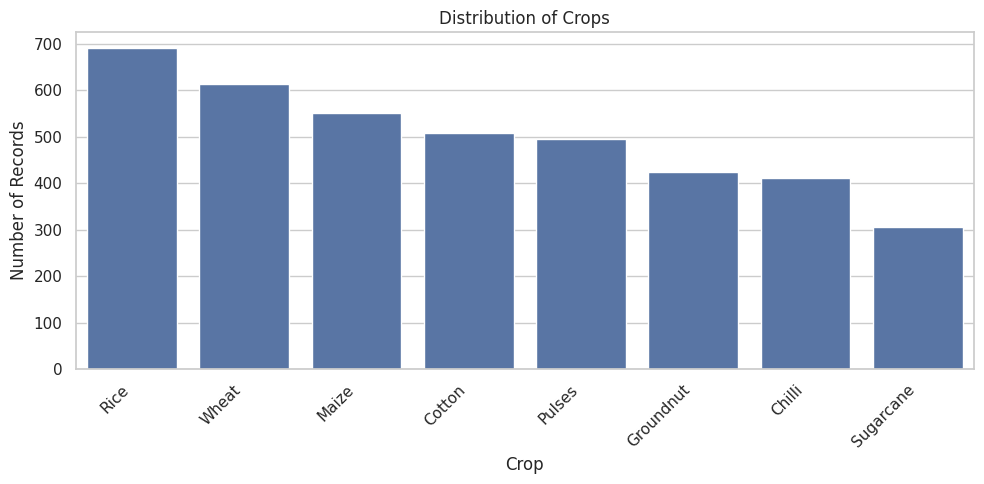

In [ ]:
 # Univariate: crop distribution,

plt.figure(figsize=(10, 5))
sns.countplot(data=data, x="Crop", order=data["Crop"].value_counts().index)

plt.xticks(rotation=45, ha="right")

plt.title("Distribution of Crops")

plt.xlabel("Crop")

plt.ylabel("Number of Records")

plt.tight_layout()

plt.show()

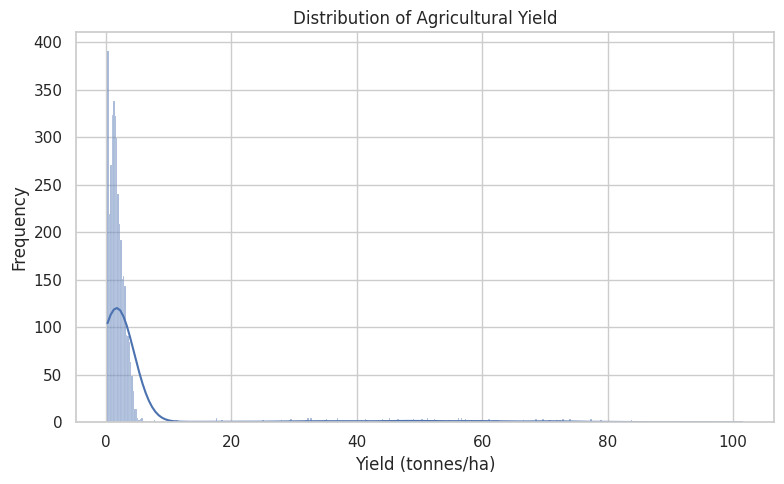

In [ ]:
#Univariate: Yield distribution

plt.figure(figsize=(8, 5))

sns.histplot(data=data, x="Yield_Tonnes_Ha", kde =True)

plt.title("Distribution of Agricultural Yield")

plt.xlabel("Yield (tonnes/ha)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

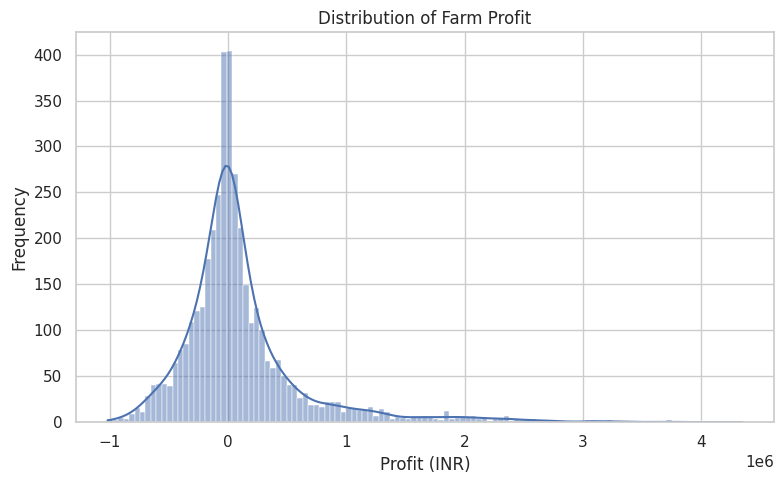

In [ ]:
#Univariate: Profit distribution

plt.figure(figsize=(8, 5))

sns.histplot(data=data, x="Profit_INR", kde= True)

plt.title("Distribution of Farm Profit")

plt.xlabel("Profit (INR)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

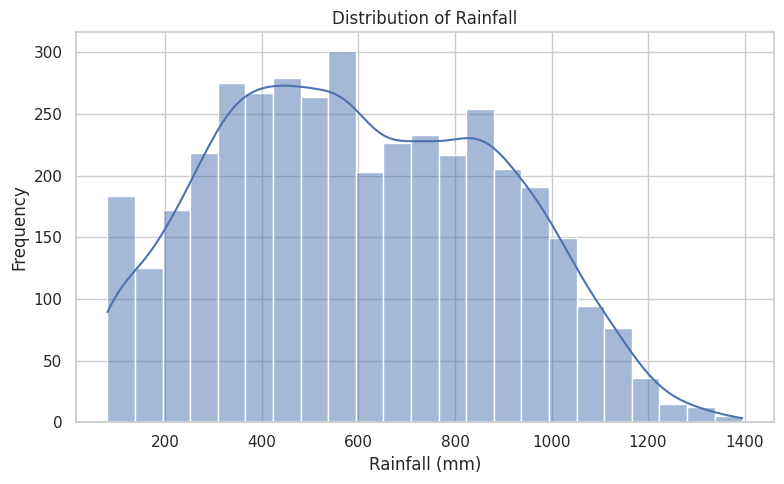

In [ ]:
  # Univariate: Rainfall distribution

plt.figure(figsize=(8, 5))

sns.histplot(data=data, x="Rainfall_mm", kde =True)

plt.title("Distribution of Rainfall")

plt.xlabel("Rainfall (mm)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

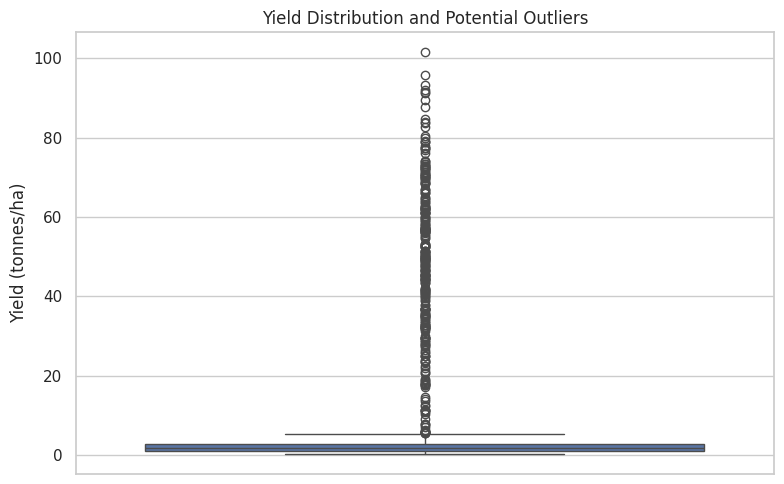

In [ ]:
#Univariate: Boxplot for yield

plt.figure(figsize=(8, 5))

sns.boxplot(data=data, y="Yield_Tonnes_Ha")

plt.title("Yield Distribution and Potential Outliers")

plt.ylabel("Yield (tonnes/ha)")

plt.tight_layout()

plt.show()

# 9. Outlier Analysis

Investigating potential outliers using statistical and visual methods.

Univariate: Season distribution (Pie Chart)

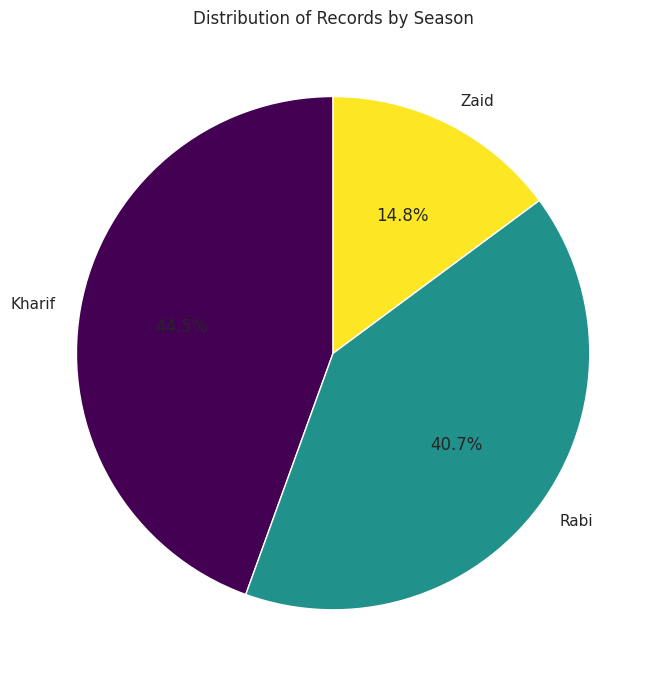

In [ ]:
plt.figure(figsize=(7, 7))

data['Season'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')

plt.title('Distribution of Records by Season')

plt.ylabel('')

plt.tight_layout()

plt.show()

In [ ]:
#IQR-based outlier summary for numerical columns
outlier_summary = []

for col in numeric_columns:

    q1 = data[col].quantile(0.25)

    q3 = data[col].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr

    upper_bound = q3 + 1.5 * iqr

    # Count outliers
    outlier_count = ((data[col] < lower_bound) | (data[col] > upper_bound)).sum()

    outlier_summary.append({

        "Column": col,

        "Lower Bound": lower_bound,

        "Upper_Bound": upper_bound,

        "Outlier_Count": outlier_count,

        "Outlier Percentage": round((outlier_count / len(data)) * 100, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary).sort_values(

    "Outlier_Count", ascending=False
)

outlier_summary_df

,Column,Lower Bound,Upper_Bound,Outlier_Count,Outlier Percentage
18,Profit_INR,"-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


# 10. Bivariate Analysis

Bivariate analysis examines relationships or differences between two variables.

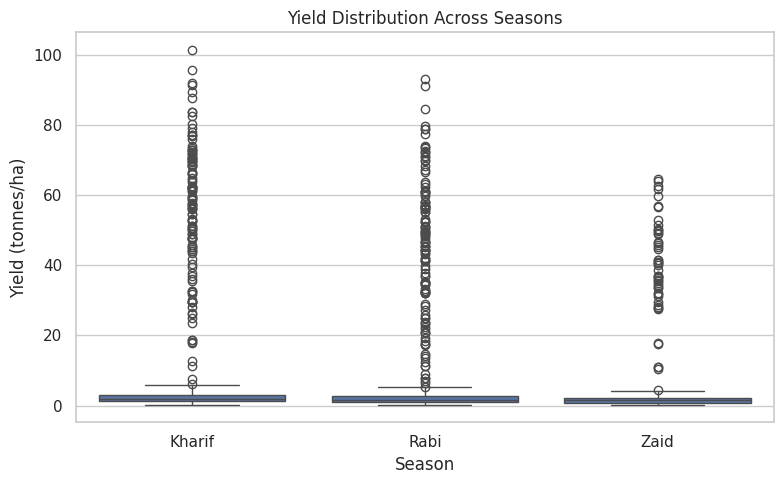

In [ ]:
#Bivariate: Season vs Yield

plt.figure(figsize=(8, 5))

sns.boxplot(data=data, x="Season", y="Yield_Tonnes_Ha")

plt.title("Yield Distribution Across Seasons")

plt.xlabel("Season")

plt.ylabel("Yield (tonnes/ha)")

plt.tight_layout()

plt.show()

# Bar plots for bivariate Analysis

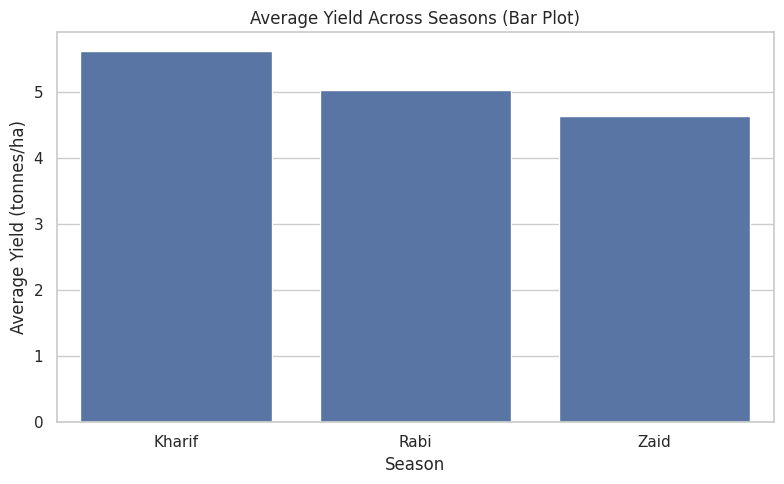

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(data=data, x="Season", y="Yield_Tonnes_Ha", errorbar=None)

plt.title("Average Yield Across Seasons (Bar Plot)")

plt.xlabel("Season")

plt.ylabel("Average Yield (tonnes/ha)")

plt.tight_layout()

plt.show()

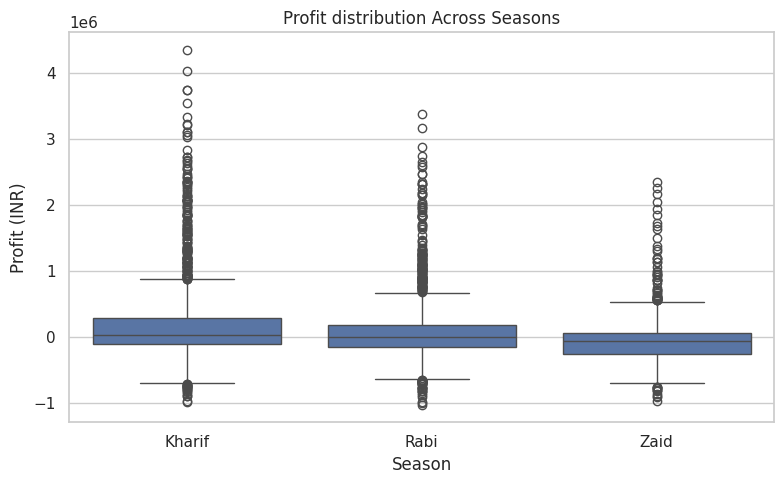

In [ ]:
#Bivariate season vs profit
plt.figure(figsize=(8, 5))

sns.boxplot(data=data, x="Season", y="Profit_INR")

plt.title("Profit distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

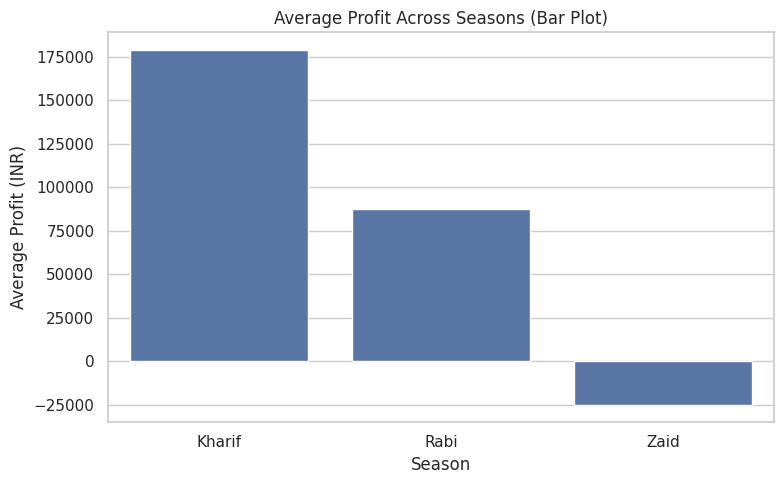

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(data=data, x="Season", y="Profit_INR", errorbar=None)
plt.title("Average Profit Across Seasons (Bar Plot)")

plt.xlabel("Season")

plt.ylabel("Average Profit (INR)")

plt.tight_layout()

plt.show()

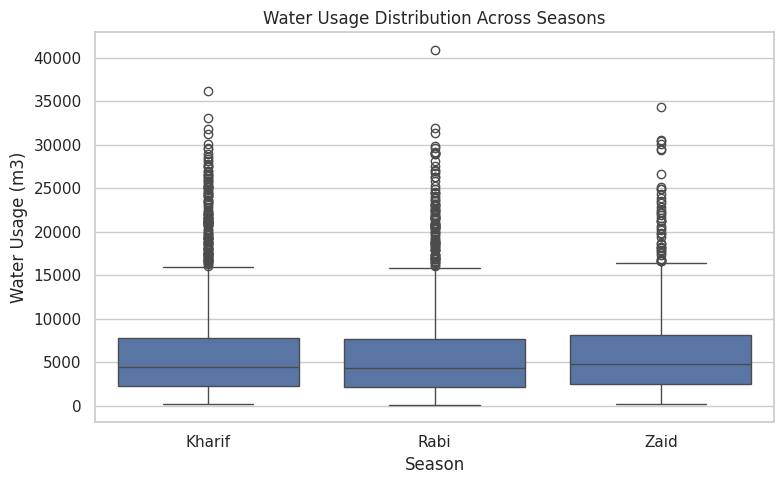

In [ ]:
# water usage across seasons

plt.figure(figsize=(8, 5))

sns.boxplot(data=data, x="Season", y="Water_Used_m3")

plt.title("Water Usage Distribution Across Seasons")

plt.xlabel("Season")

plt.ylabel("Water Usage (m3)")

plt.tight_layout()

plt.show()

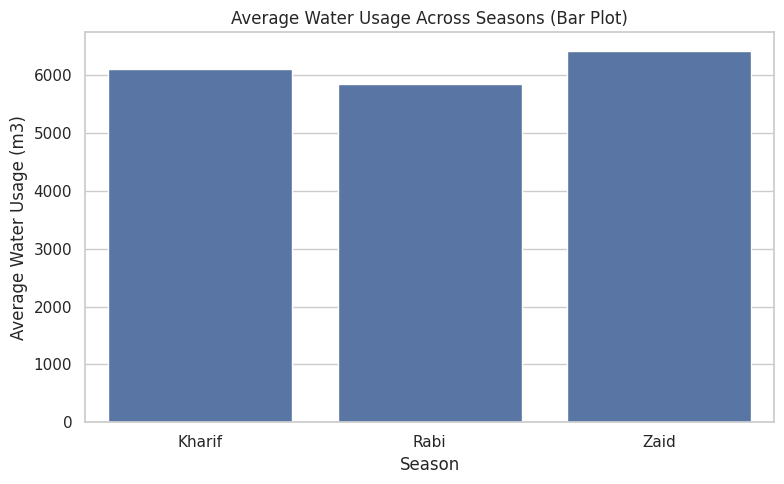

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(data=data, x="Season", y="Water_Used_m3", errorbar=None)

plt.title("Average Water Usage Across Seasons (Bar Plot)")

plt.xlabel("Season")

plt.ylabel("Average Water Usage (m3)")

plt.tight_layout()

plt.show()

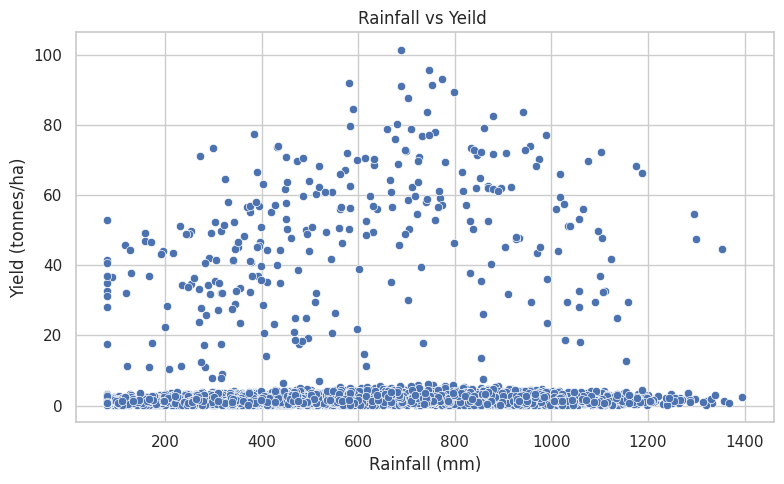

In [ ]:
# bivariate : Rainfall vs Yeild

plt.figure(figsize=(8, 5))

sns.scatterplot(data=data, x="Rainfall_mm", y="Yield_Tonnes_Ha")

plt.title("Rainfall vs Yeild ")

plt.xlabel("Rainfall (mm)")

plt.ylabel("Yield (tonnes/ha)")

plt.tight_layout()

plt.show()

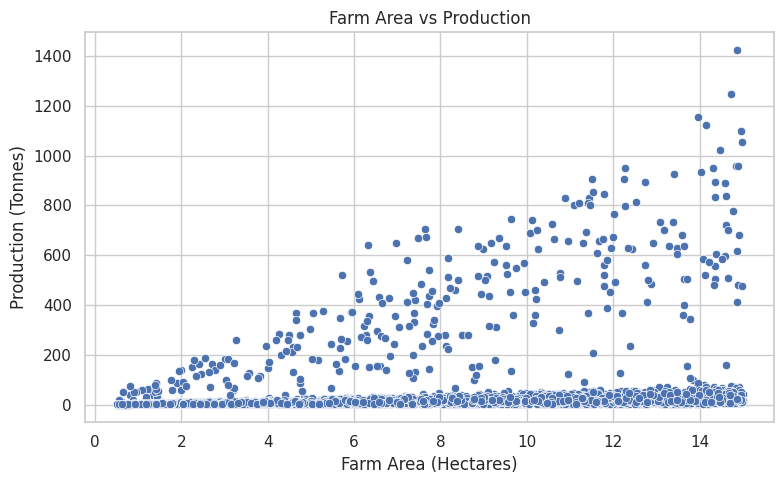

In [ ]:
#Bivariate : farm area vs production
plt.figure(figsize=(8, 5))

sns.scatterplot(data=data, x="Farm_Area_Hectares", y="Production_Tonnes")

plt.title("Farm Area vs Production")

plt.xlabel("Farm Area (Hectares)")

plt.ylabel("Production (Tonnes)")

plt.tight_layout()

plt.show()

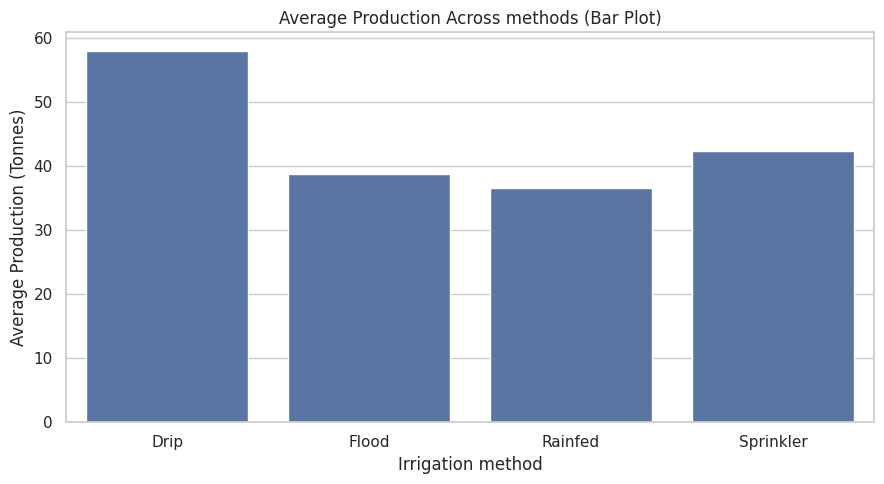

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(data=data, x="Irrigation_Method", y="Production_Tonnes", errorbar=None)

plt.title("Average Production Across methods (Bar Plot)")

plt.xlabel("Irrigation method")

plt.ylabel("Average Production (Tonnes)")

plt.tight_layout()

plt.show()

# 11. Multivariate Analysis

Multivariate analysis examines more than two variables together.

Use multivariate plots to investigate how season interacts with other dimensions such as crop, region, environmental conditions, resource usage or economic performance.

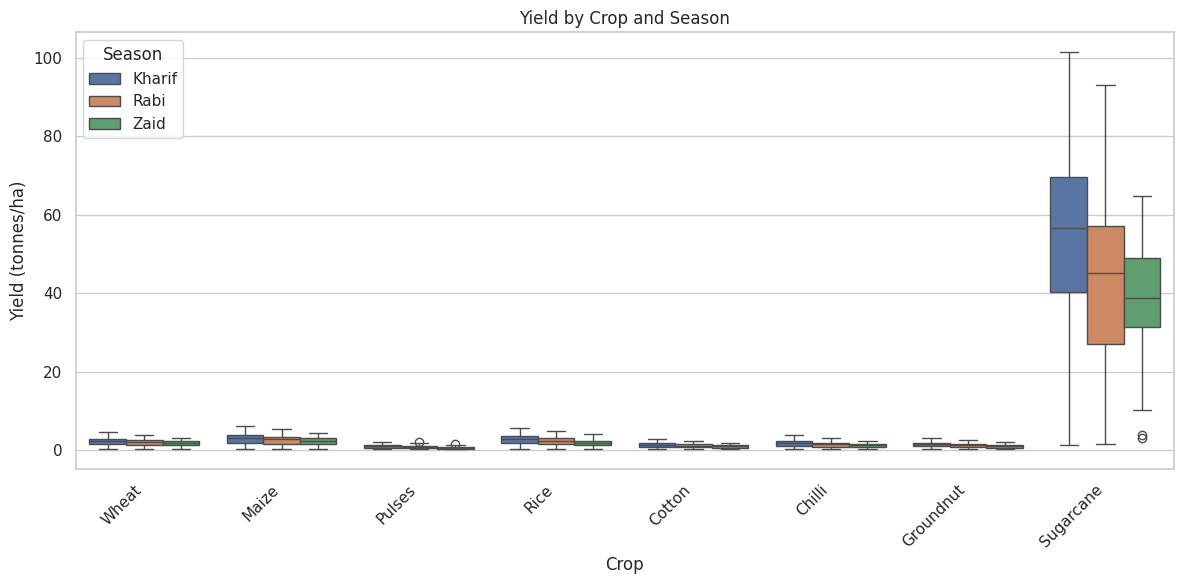

In [ ]:
#Multivariate: Season, crop and yield

plt.figure(figsize=(12, 6))

sns.boxplot(data=data, x="Crop", y="Yield_Tonnes_Ha", hue="Season")

plt.xticks(rotation=45, ha="right")

plt.title("Yield by Crop and Season")

plt.xlabel("Crop")

plt.ylabel("Yield (tonnes/ha)")

plt.legend(title="Season")

plt.tight_layout()

plt.show()

# Multivariate : Grouped Bar Plot of Average Yeild by Crop and Section

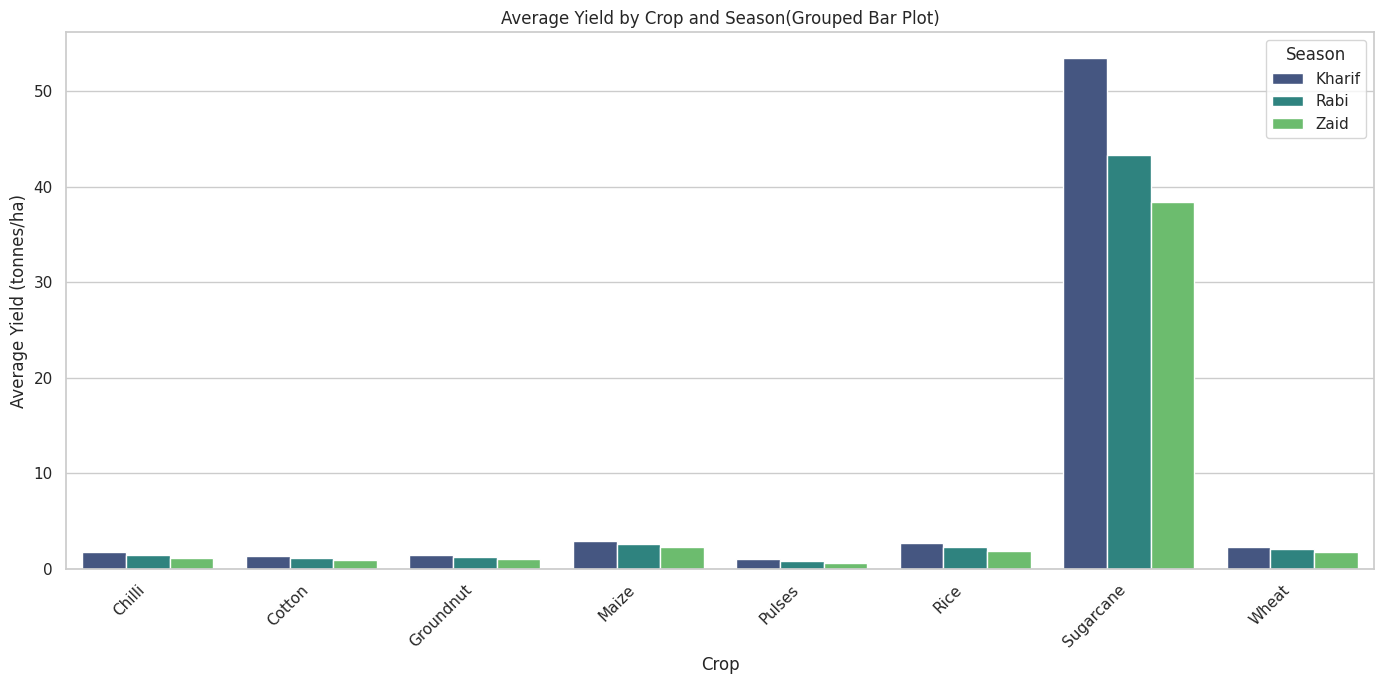

In [ ]:
crop_season_summary = data.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].mean().reset_index(name='Average_yield')

plt.figure(figsize=(14,7))
sns.barplot(data=crop_season_summary, x="Crop", y="Average_yield", hue="Season",palette="viridis")
plt.title("Average Yield by Crop and Season(Grouped Bar Plot)")
plt.xlabel("Crop")
plt.ylabel("Average Yield (tonnes/ha)")
plt.xticks(rotation=45,ha="right")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

Multivariate : Pair Plot of Key Environmental and Perfomance Metrics by Season

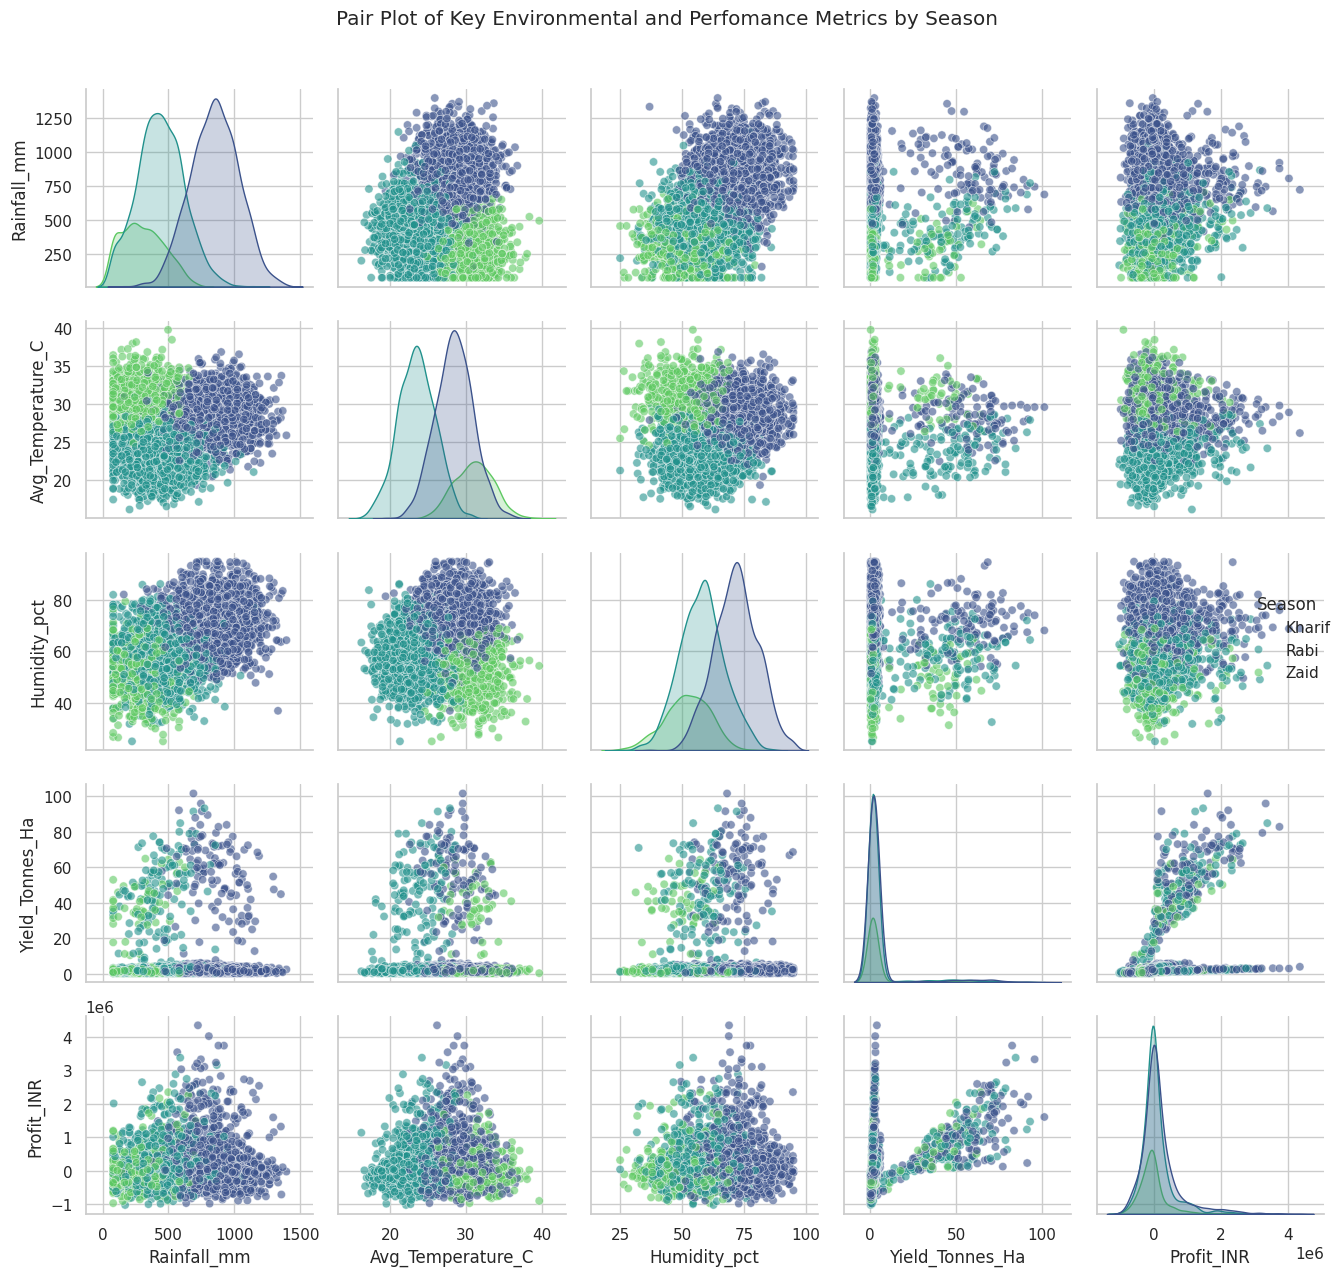

In [ ]:
selected_columns = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct','Yield_Tonnes_Ha','Profit_INR','Season']
sns.pairplot(data[selected_columns], hue='Season',palette='viridis',plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Key Environmental and Perfomance Metrics by Season', y=1.02)
plt.tight_layout()
plt.show()

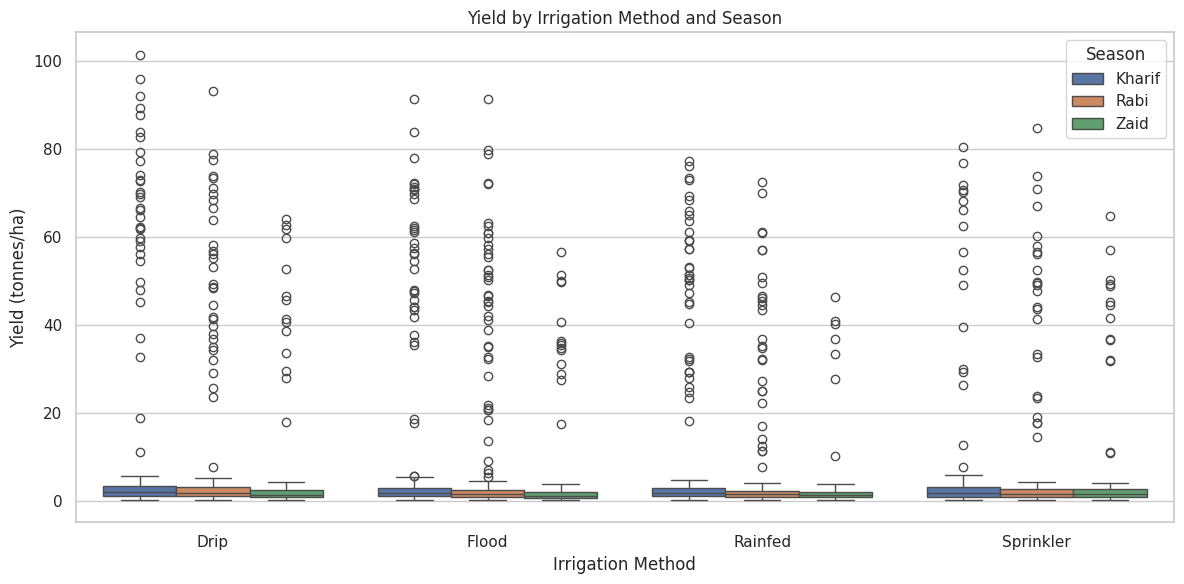

In [ ]:
#multivariate: season,irrigates and yeild
plt.figure(figsize=(12, 6))

sns.boxplot(data=data, x="Irrigation_Method", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

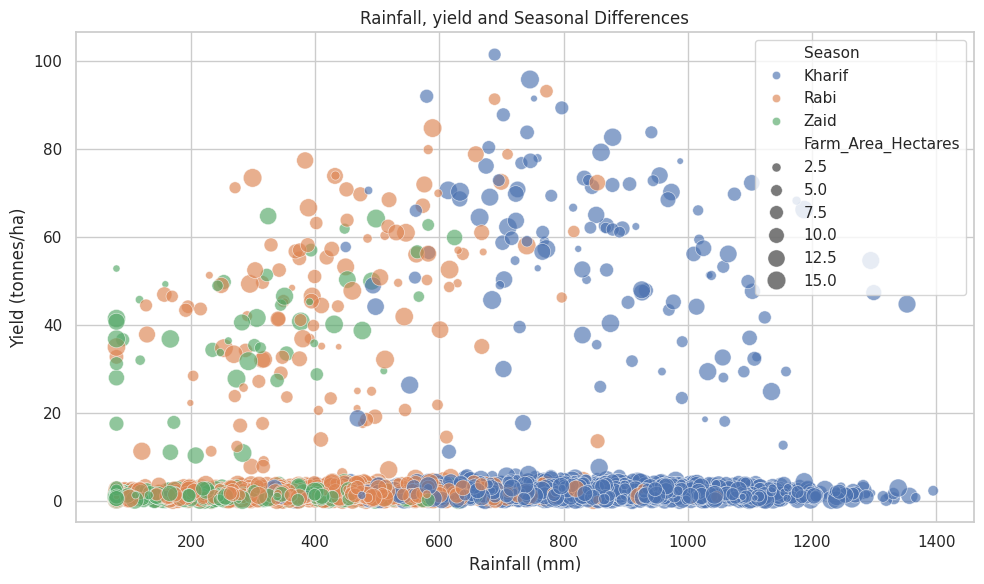

In [ ]:
#rainfall,yeild and seasonal differences
plt.figure(figsize=(10, 6))

sns.scatterplot(

data=data,

x="Rainfall_mm",

y="Yield_Tonnes_Ha",

hue="Season",

size="Farm_Area_Hectares",

sizes=(20, 180),

alpha=0.65
)

plt.title("Rainfall, yield and Seasonal Differences")

plt.xlabel("Rainfall (mm)")

plt.ylabel("Yield (tonnes/ha)")

plt.tight_layout()

plt.show()

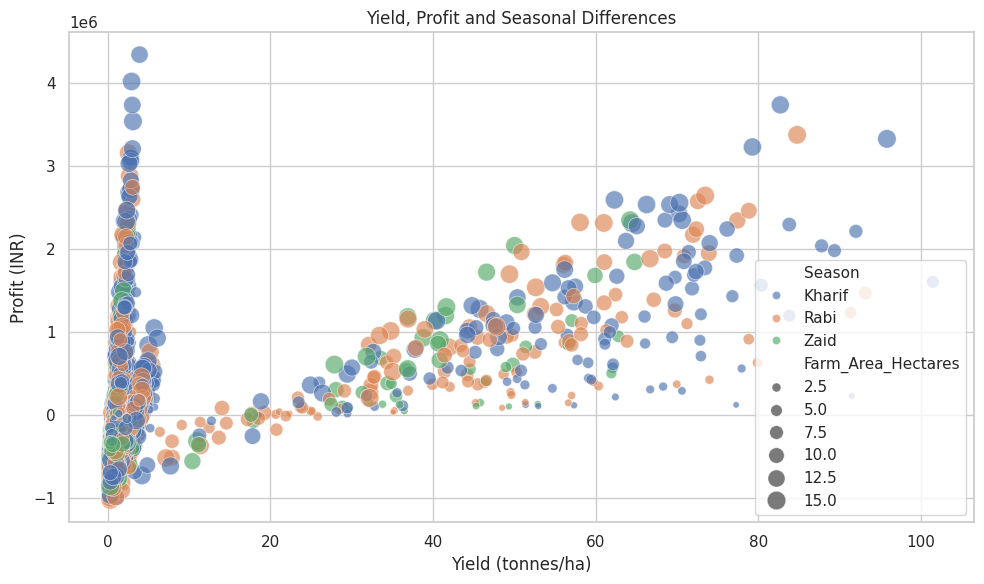

In [ ]:
# Multivariate: Profit, yield and season

plt.figure(figsize=(10, 6))

sns.scatterplot(

data=data,

x="Yield_Tonnes_Ha",

y="Profit_INR",

hue="Season",

size="Farm_Area_Hectares",

sizes=(20, 180),

alpha=0.65
)

plt.title("Yield, Profit and Seasonal Differences")

plt.xlabel("Yield (tonnes/ha)")

plt.ylabel("Profit (INR)")

plt.tight_layout()

plt.show()

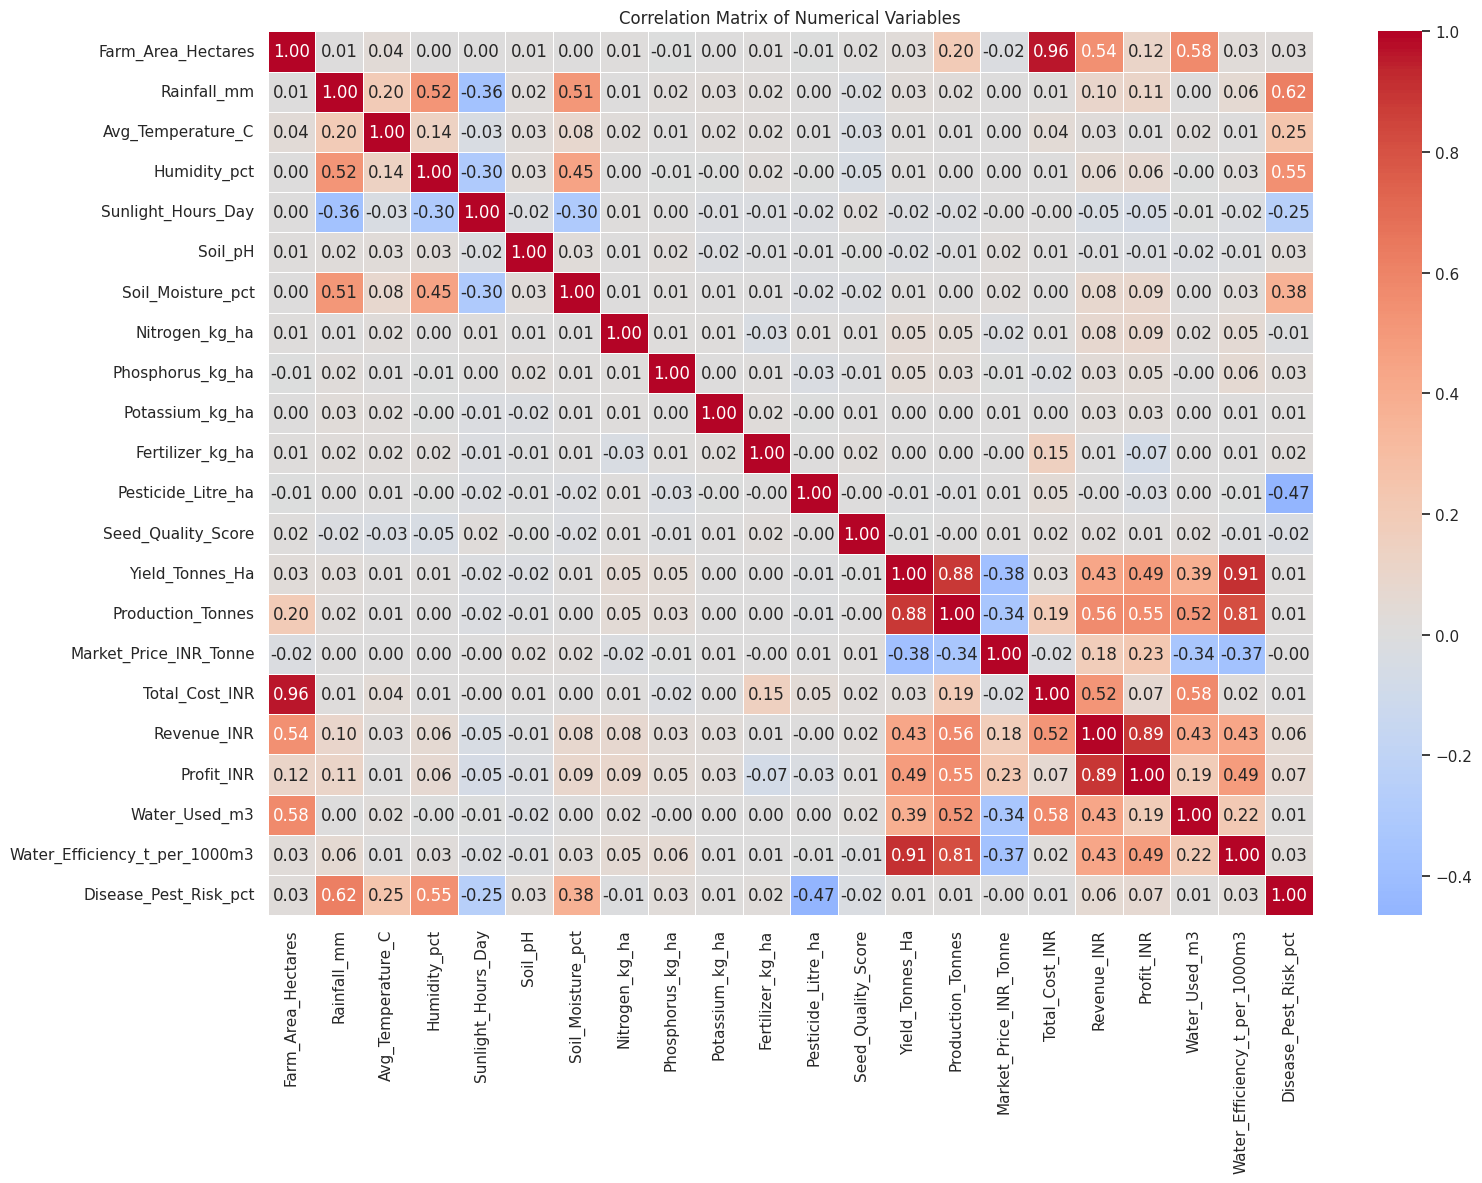

In [ ]:
#Correlation heatmap for numerical variables

plt.figure(figsize=(16, 12))
corr=data[numeric_columns].corr(numeric_only=True)

sns.heatmap(


corr,

annot=True,

fmt=".2f",

cmap="coolwarm",

center=0,

linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()

plt.show()

# 12. Seasonal Comparison

Individual plots to structured comparisons.

In [ ]:
season_metrics = data.groupby("Season").agg(

     Records=("Farm_ID", "count"),
     Average_Yield=("Yield_Tonnes_Ha", "mean"),

     Total_Production=("Production_Tonnes", "sum"),

     Average_Profit=("Profit_INR", "mean"),

     Total_Profit=("Profit_INR", "sum"),

     Average_Water_Used=("Water_Used_m3", "mean")

 ).round (2)

season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.63,"82,387.61","178,914.65",318289158,"6,102.20"
Rabi,1627,5.04,"67,498.88","87,689.47",142670768,"5,846.99"
Zaid,594,4.64,"23,098.35","-24,804.82",-14734066,"6,419.89"


# 13.Student Designed Analysis

Student Analysis 1 — Average Profit by Crop

In [ ]:
# Student Analysis 1: Profit by Crop

crop_profit = data.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)

print("Average Profit by Crop:")
print(crop_profit.round(2))

Average Profit by Crop:
Crop
Sugarcane    817,187.99
Chilli       750,878.34
Cotton       124,546.92
Groundnut     44,858.12
Pulses        -4,238.05
Maize        -83,978.33
Rice        -102,213.50
Wheat       -123,398.34
Name: Profit_INR, dtype: float64


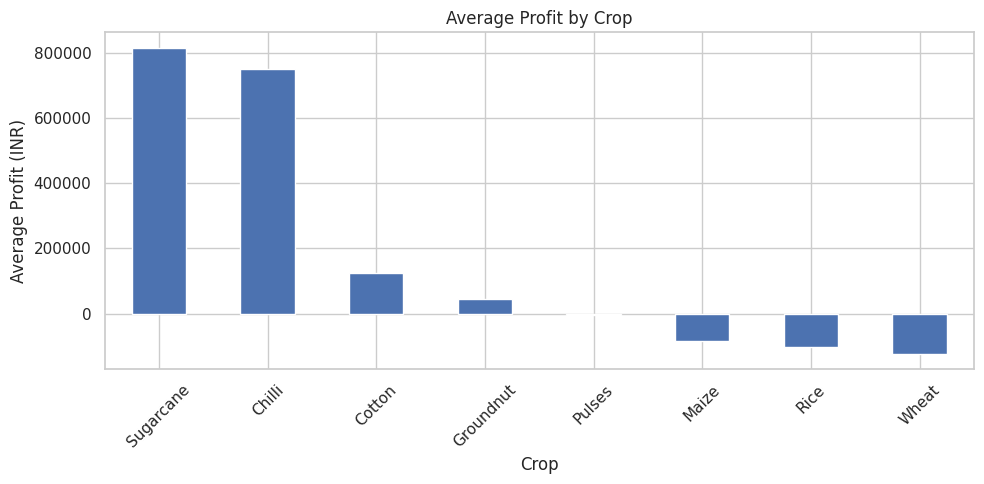

In [ ]:
plt.figure(figsize=(10, 5))

crop_profit.plot(kind='bar')

plt.title('Average Profit by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

This analysis compares the average profit generated by different crops. It helps identify which crops provide better financial returns and can support better crop selection decisions.

Student Analysis 2 — Fertilizer vs Yield

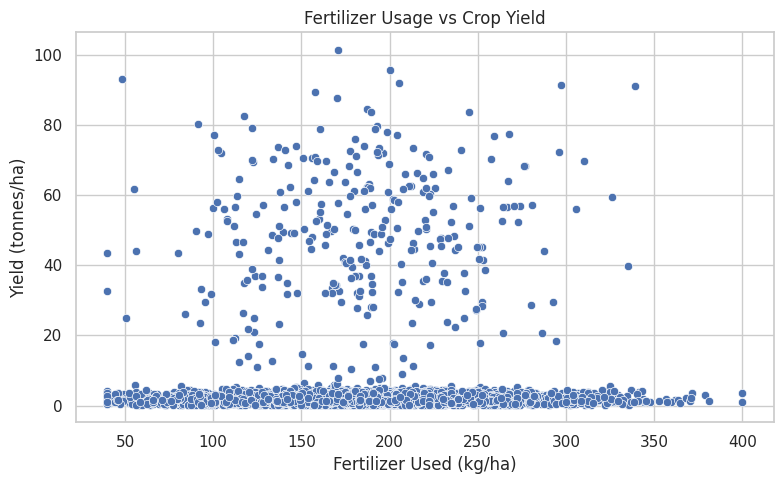

In [ ]:
# Student Analysis 2: Fertilizer and Yield

plt.figure(figsize=(8, 5))

sns.scatterplot(
data=data,
x='Fertilizer_kg_ha',
y='Yield_Tonnes_Ha'
)

plt.title('Fertilizer Usage vs Crop Yield')
plt.xlabel('Fertilizer Used (kg/ha)')
plt.ylabel('Yield (tonnes/ha)')

plt.tight_layout()
plt.show()

In [ ]:
correlation = data['Fertilizer_kg_ha'].corr(data['Yield_Tonnes_Ha'])

print("Correlation between Fertilizer Usage and Yield:", round(correlation, 3))

Correlation between Fertilizer Usage and Yield: 0.0


This analysis examines the relationship between fertilizer usage and crop yield. The scatter plot and correlation value help understand whether fertilizer usage is associated with changes in agricultural yield.

Student Analysis 3 — Disease/Pest Risk and Yield

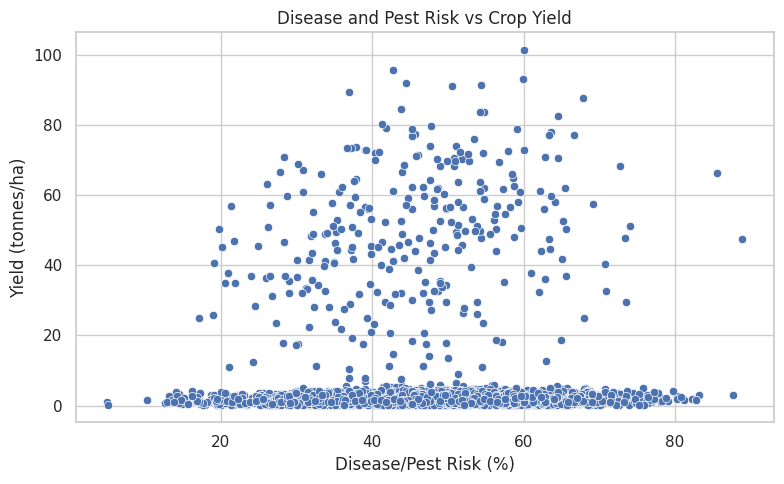

In [ ]:
# Student Analysis 3: Disease/Pest Risk and Yield

plt.figure(figsize=(8, 5))

sns.scatterplot(
data=data,
x='Disease_Pest_Risk_pct',
y='Yield_Tonnes_Ha'
)
plt.title('Disease and Pest Risk vs Crop Yield')
plt.xlabel('Disease/Pest Risk (%)')
plt.ylabel('Yield (tonnes/ha)')

plt.tight_layout()
plt.show()

In [ ]:
correlation = data['Disease_Pest_Risk_pct'].corr( data['Yield_Tonnes_Ha'])
print("Correlation between Disease/Pest Risk and Yield:",  round(correlation, 3))


Correlation between Disease/Pest Risk and Yield: 0.014


This analysis examines whether disease and pest risk is associated with agricultural yield. It provides an additional perspective on how crop health conditions may be related to production performance.

# 14.key Insights

1.Kharif season showed the highest average crop yield compared with Rabi and Zaid seasons.

2.Agricultural performance varies across seasons, showing that season plays an important role in crop production.

3.Crop performance differs from one crop to another, with some crops giving better yield and profit than others.

4.Water usage varies across seasons, indicating the importance of efficient irrigation and water management.

5.Rainfall has a relationship with crop yield, showing that environmental conditions can influence agricultural performance.

6.Fertilizer usage is related to crop yield, so proper fertilizer management can support better production.

7.Higher disease and pest risk can affect crop yield, highlighting the need for regular monitoring and preventive measures.

8.Profit differs across crops and seasons, so selecting the right crop and season can help improve farm profitability.


# 15. Evidence-Based Recommendations

Recommendations

1.Focus on high-performing seasons: Kharif showed the highest average yield, so suitable crops can be prioritized during this season.

2.Select crops based onperformance: Crop-wise analysis can be used to select crops that provide better yield and profit.

3.Use water efficiently: Water usage varies across seasons, so efficient irrigation methods should be preferred to reduce unnecessary water consumption.

4.Manage fertilizer carefully: Fertilizer usage should be monitored and applied according to crop requirements to maintain good yield without unnecessary input costs.

5.Monitor disease and pest risk: Regular monitoring and timely preventive measures can help reduce production losses caused by pests and diseases.

# 16. Limitations

Limitations
1.  The analysis is based only on the available dataset and may not represent all farming conditions.
2.  Some important factors such as weather changes, soil quality, and market conditions may affect agricultural performance but are not fully considered.
3.  The dataset contains some outliers that may affect the analysis results.
4.  The analysis shows relationships between variables, but it does not prove cause-and-effect relationships.
5.  The results may change if more data from different years, regions, or farms are included.


# 17. Final Conclusion

Final Conclusion

This project analyzed seasonal agricultural performance using Python and different data analysis techniques. The analysis helped to understand crop yield, production, profit, water usage, and environmental factors across different seasons. The results showed that agricultural performance varies between seasons and crops, with Kharif showing better average yield than Rabi and Zaid. The analysis also helped identify relationships, outliers, and important factors affecting agricultural performance. Overall, the findings can help farmers and decision-makers make better decisions about crop selection, resource usage, and seasonal planning.

18. Project Checklist

Dataset loaded successfully

Top 5 rows analyzed

Dataset shape and structure examined

Data types examined

Missing values identified and handled

Duplicate recordes identified and handled

Descriptive/statistical analysis performed

Outliers investigated

Univariate analysis completed

Bivariate analysis completed

Multivariate analysis completed

Correlation analysis completed

Seasonal comparisons performed

At least 3 student-designed analyses completed

At least 8 meaningful insights documented

Evidence based recommendations provided

Limitations discussed

Final conclusion provided


---